# 📱 Unveiling the Android App Market — Google Play Store Analysis
### Oasis Infobyte Internship — Data Analytics | Level 2, Task 4
**Name:** Param Parag Koli
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Datasets & Initial Inspection

In [2]:
apps = pd.read_csv('/content/googleplaystore.csv')
reviews = pd.read_csv('/content/googleplaystore_user_reviews.csv')

print("Apps Dataset Shape:", apps.shape)
print("\nApps Column Names:", apps.columns.tolist())
print("\nNull Values in Apps:\n", apps.isnull().sum())
print("\n" + "="*50)
print("\nReviews Dataset Shape:", reviews.shape)
print("\nReviews Column Names:", reviews.columns.tolist())
print("\nNull Values in Reviews:\n", reviews.isnull().sum())

apps.head()

Apps Dataset Shape: (10841, 13)

Apps Column Names: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Null Values in Apps:
 App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Reviews Dataset Shape: (64295, 5)

Reviews Column Names: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Null Values in Reviews:
 App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 🧹 Step 2 — Data Cleaning

In [5]:
apps = apps.drop_duplicates(subset='App')
apps = apps[apps['Android Ver'] != '1.9']

apps = apps[apps['Installs'] != 'Free']
apps = apps[apps['Installs'].notna()]
apps['Installs'] = apps['Installs'].str.replace('[+,]', '', regex=True).astype(float)
apps['Price'] = apps['Price'].str.replace('$', '', regex=False).astype(float)
apps['Size'] = apps['Size'].str.replace('M', '', regex=False)
apps['Size'] = apps['Size'].str.replace('k', '', regex=False)
apps['Size'] = pd.to_numeric(apps['Size'], errors='coerce')
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')

apps = apps.dropna(subset=['Rating'])

print("Cleaned Apps Shape:", apps.shape)
apps.head()

Cleaned Apps Shape: (8196, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 📊 Step 3 — Category Analysis

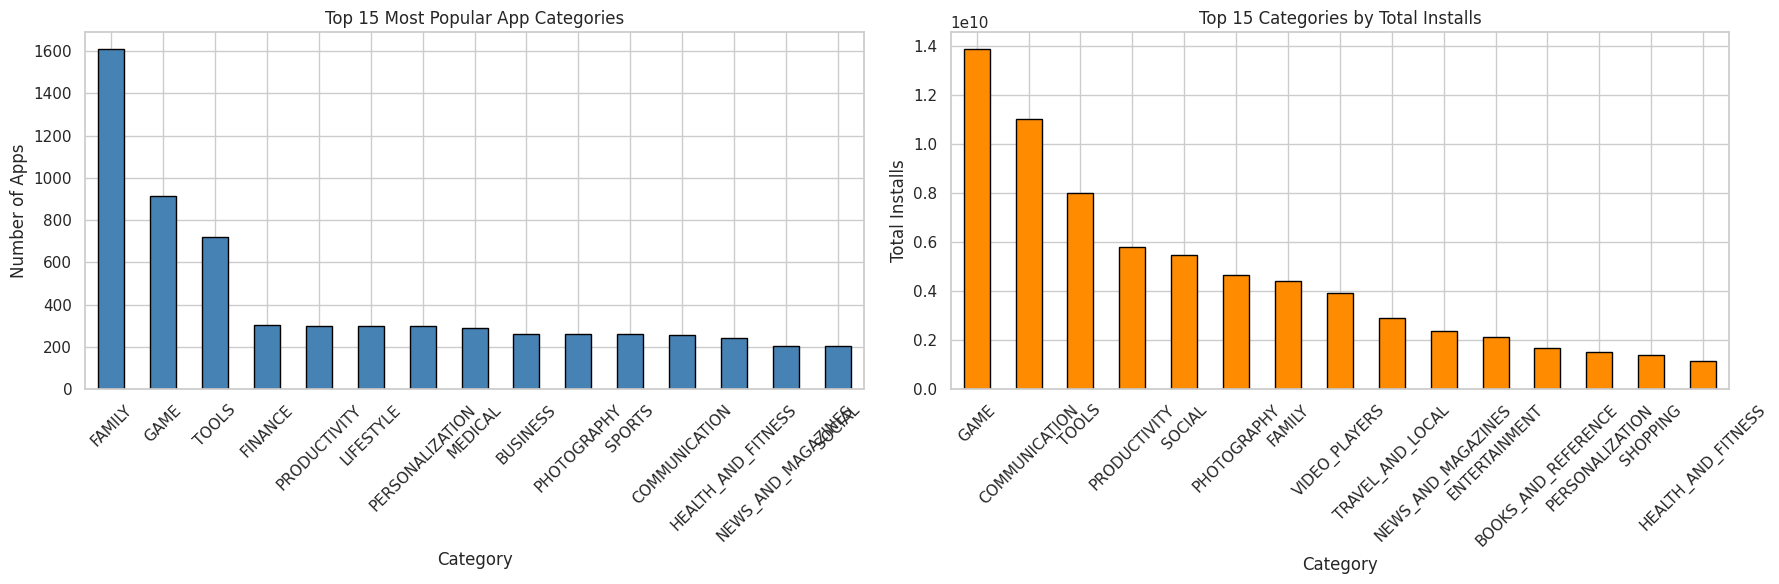

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

category_counts = apps['Category'].value_counts().head(15)
category_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 Most Popular App Categories')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Apps')
axes[0].tick_params(axis='x', rotation=45)

category_installs = apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(15)
category_installs.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Top 15 Categories by Total Installs')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Installs')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## ⭐ Step 4 — Ratings Analysis

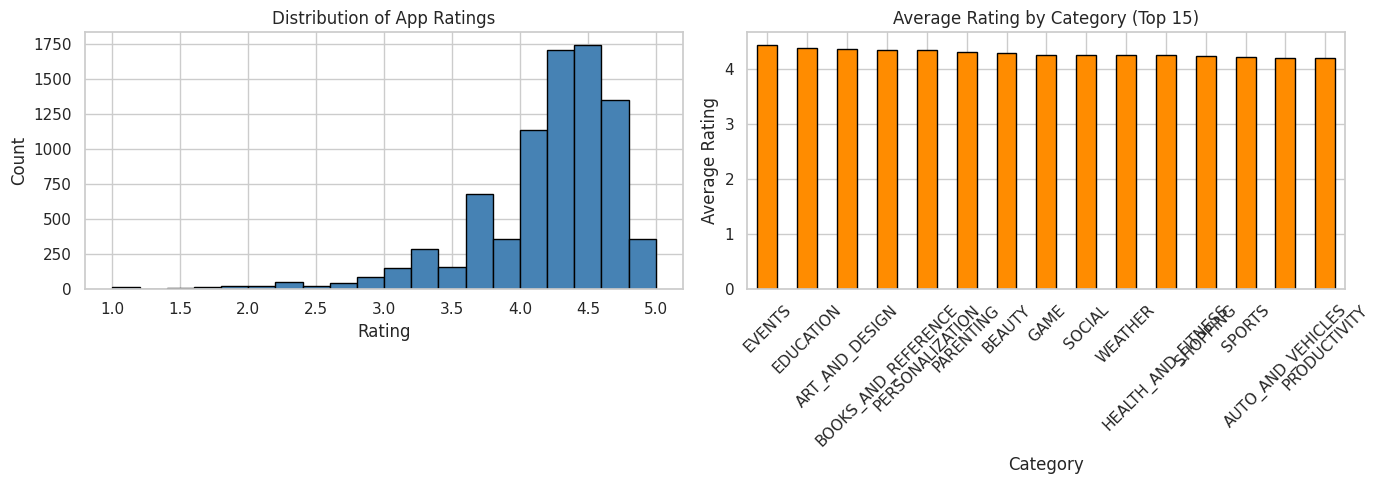

Overall Average Rating: 4.17


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(apps['Rating'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of App Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

avg_rating_by_category = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(15)
avg_rating_by_category.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Average Rating by Category (Top 15)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Overall Average Rating:", round(apps['Rating'].mean(), 2))

## 📦 Step 5 — Size & Installs Analysis

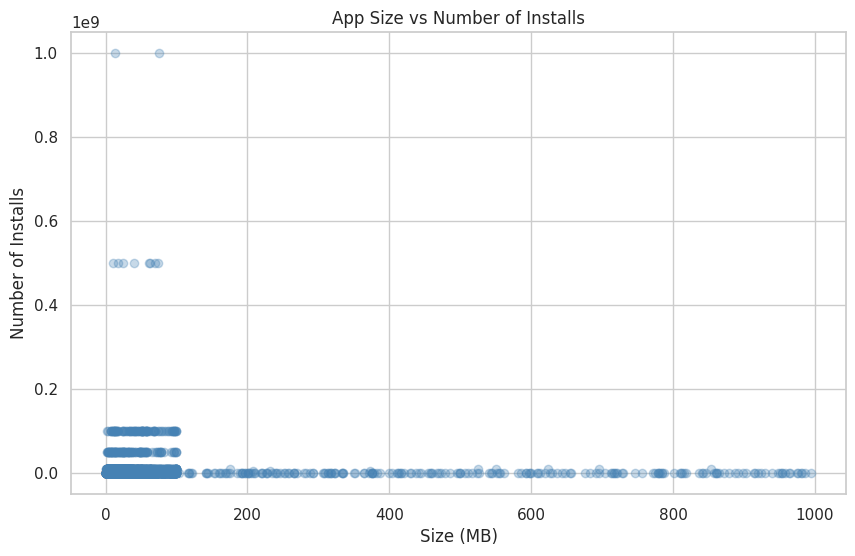

Correlation between Size and Installs: 0.0071


In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(apps['Size'], apps['Installs'], alpha=0.3, color='steelblue')
plt.title('App Size vs Number of Installs')
plt.xlabel('Size (MB)')
plt.ylabel('Number of Installs')
plt.show()

print("Correlation between Size and Installs:", round(apps['Size'].corr(apps['Installs']), 4))

## 💰 Step 6 — Pricing Analysis

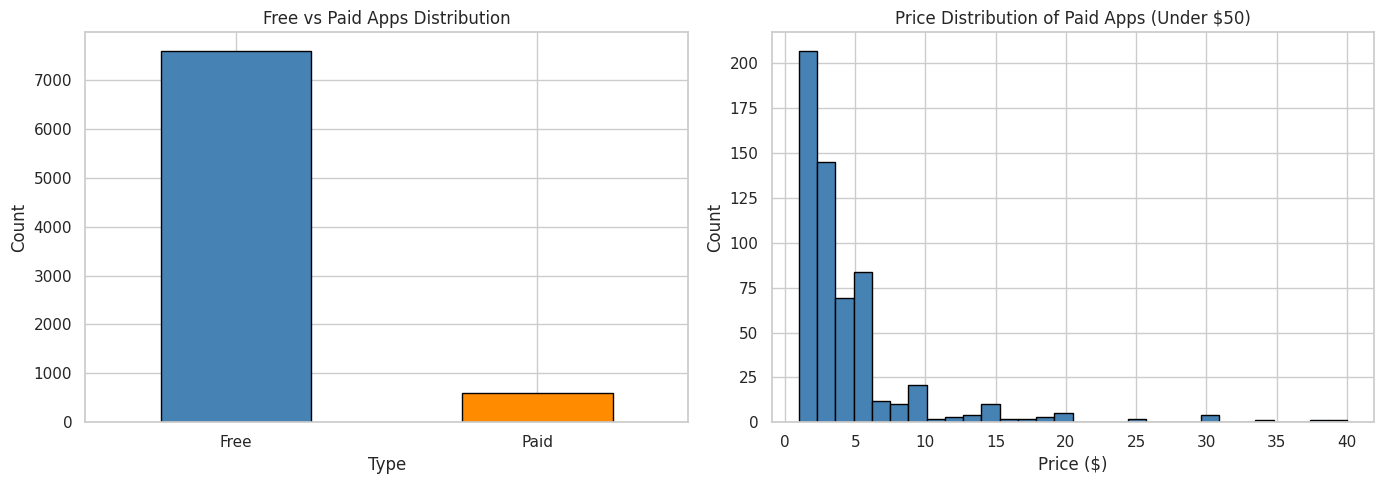

Total Free Apps: 7592
Total Paid Apps: 604
Average Price of Paid Apps: $ 14.08


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

apps['Type'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_title('Free vs Paid Apps Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

paid_apps = apps[apps['Price'] > 0]
paid_apps[paid_apps['Price'] < 50]['Price'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Price Distribution of Paid Apps (Under $50)')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Total Free Apps:", len(apps[apps['Price'] == 0]))
print("Total Paid Apps:", len(apps[apps['Price'] > 0]))
print("Average Price of Paid Apps: $", round(paid_apps['Price'].mean(), 2))

## 💬 Step 7 — Sentiment Analysis on User Reviews

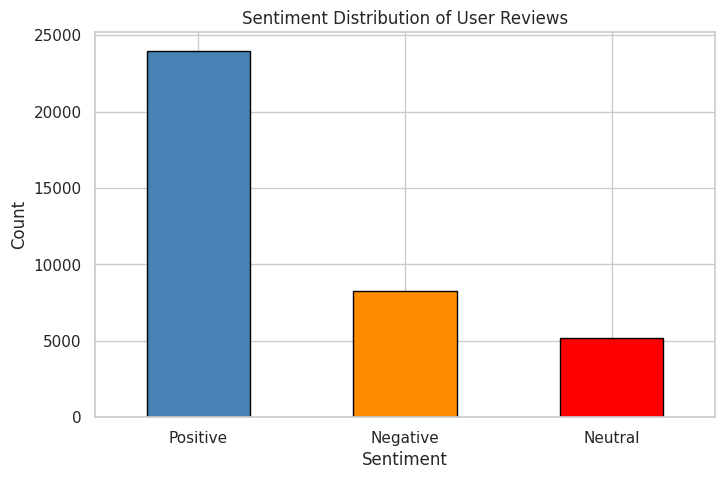

Sentiment Distribution:
 Sentiment
Positive    23997
Negative     8272
Neutral      5158
Name: count, dtype: int64


In [10]:
reviews = reviews.dropna(subset=['Translated_Review'])

def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

reviews['Sentiment'] = reviews['Translated_Review'].apply(get_sentiment)

plt.figure(figsize=(8, 5))
reviews['Sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'darkorange', 'red'], edgecolor='black')
plt.title('Sentiment Distribution of User Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print("Sentiment Distribution:\n", reviews['Sentiment'].value_counts())

## 📊 Step 8 — Sentiment by Category

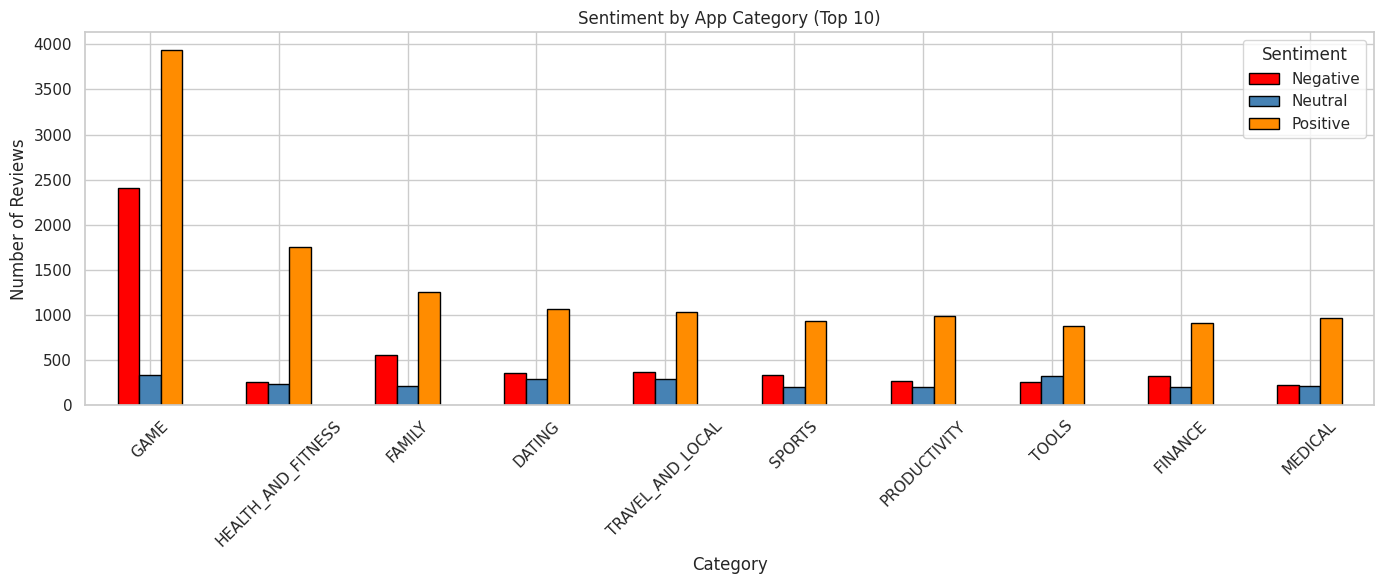

In [11]:
merged = reviews.merge(apps[['App', 'Category']], on='App', how='left')
merged = merged.dropna(subset=['Category'])

sentiment_by_category = merged.groupby(['Category', 'Sentiment']).size().unstack(fill_value=0)
sentiment_by_category = sentiment_by_category.loc[sentiment_by_category.sum(axis=1).sort_values(ascending=False).head(10).index]

sentiment_by_category.plot(kind='bar', figsize=(14, 6), color=['red', 'steelblue', 'darkorange'], edgecolor='black')
plt.title('Sentiment by App Category (Top 10)')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## 📝 Step 9 — Observations & Conclusion

### Key Observations

1. **Category Analysis** — The Family and Game categories have the highest number of apps, making them the most saturated markets. However, Communication and Social categories lead in total installs, indicating higher user demand.

2. **Ratings Analysis** — Most apps are rated between 4.0 and 4.5, suggesting that the Play Store has a generally high quality bar. Health & Fitness and Books & Reference categories have the highest average ratings.

3. **Size vs Installs** — There is a weak positive correlation between app size and number of installs. Larger apps do not necessarily get more downloads, suggesting that app quality matters more than size.

4. **Pricing Analysis** — The vast majority of apps are free. Most paid apps are priced under $10, with very few premium apps above $50.

5. **Sentiment Analysis** — Positive sentiment dominates user reviews across all categories, indicating general user satisfaction. However, Game and Family categories show a higher proportion of negative reviews compared to other categories.

6. **Sentiment by Category** — Communication and Social apps receive the most reviews overall, while Tools and Productivity apps tend to have more balanced sentiment distributions.

### ✅ Conclusion & Business Recommendations

1. **Launch in underserved but high-install categories** — Rather than entering saturated markets like Family or Game, new developers should target categories like Communication or Productivity where installs are high but competition is lower.
2. **Keep apps lightweight** — Since app size has weak correlation with installs, developers should focus on optimising app size to improve download rates, especially in markets with limited data plans.
3. **Monitor sentiment in Game and Family categories** — The higher proportion of negative reviews in these categories suggests opportunities for improvement in user experience, which could lead to higher ratings and more installs.

## 🏁 End of Analysis
**Analyst:** Param Parag Koli
**Track:** Data Analytics
**Task:** Level 2 — Task 4 · Unveiling the Android App Market
**Batch:** July 2026
**Internship:** Oasis Infobyte Summer Internship Program